In [18]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('bank-full.csv', sep=';')
print('Data shape:', df.shape)
df.head()

Data shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [19]:
df.info()

num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
cat_cols = [c for c in df.columns if c not in num_cols and c != 'y']
print('\nNumeric columns    :', len(num_cols), num_cols)
print('Categorical columns:', len(cat_cols), cat_cols)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Numeric columns    : 7 ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Cate

In [20]:
print('Standard isnull() count:', df.isnull().sum().sum())
print("Cells holding string 'unknown':", (df == 'unknown').sum().sum())

df_nan = df.replace('unknown', np.nan)
missing = pd.DataFrame({
    'missing_count': df_nan.isna().sum(),
    'missing_pct': (df_nan.isna().mean() * 100).round(2),
})
missing = missing[missing.missing_count > 0].sort_values(
    'missing_count', ascending=False
)
missing

Standard isnull() count: 0
Cells holding string 'unknown': 52124


,missing_count,missing_pct
poutcome,36959,81.75
contact,13020,28.80
education,1857,4.11
job,288,0.64


In [23]:
dupes = df.duplicated().sum()
print(f'Exact duplicate rows: {dupes} ({dupes / len(df) * 100:.2f}%)')

Exact duplicate rows: 0 (0.00%)


In [25]:
print(
    'Clients with negative balance (overdrafts):',
    (df['balance'] < 0).sum(),
    f"({(df['balance'] < 0).mean() * 100:.2f}%)",
)
print(
    'pdays == -1 (never contacted before):',
    (df['pdays'] == -1).sum(),
    f"({(df['pdays'] == -1).mean() * 100:.2f}%)",
)
print('Calls lasting over 15 minutes (>900s):', (df['duration'] > 900).sum())
print(
    f"Maximum call duration: {df['duration'].max()} seconds"
    f" ({df['duration'].max() / 60:.1f} mins)"
)

Clients with negative balance (overdrafts): 3766 (8.33%)
pdays == -1 (never contacted before): 36954 (81.74%)
Calls lasting over 15 minutes (>900s): 1418
Maximum call duration: 4918 seconds (82.0 mins)


In [26]:
summary = df[num_cols].describe().T
summary['median'] = df[num_cols].median()
summary['skewness'] = df[num_cols].skew()
summary[['mean', 'median', 'std', 'min', 'max', 'skewness']].round(2)

,mean,median,std,min,max,skewness
age,40.94,39.0,10.62,18.0,95.0,0.68
balance,1362.27,448.0,3044.77,-8019.0,102127.0,8.36
day,15.81,16.0,8.32,1.0,31.0,0.09
duration,258.16,180.0,257.53,0.0,4918.0,3.14
campaign,2.76,2.0,3.10,1.0,63.0,4.90
pdays,40.20,-1.0,100.13,-1.0,871.0,2.62
previous,0.58,0.0,2.30,0.0,275.0,41.85


In [59]:
outlier_profile = []
for c in num_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    n_lower = (df[c] < lower_fence).sum()
    n_upper = (df[c] > upper_fence).sum()
    n_total = n_lower + n_upper

    outlier_profile.append({
        'Feature': c,
        'Min': df[c].min(),
        'Q1 (25%)': round(q1, 1),
        'Median': df[c].median(),
        'Q3 (75%)': round(q3, 1),
        'Max': df[c].max(),
        'IQR': round(iqr, 1),
        'Lower Fence': round(lower_fence, 1),
        'Upper Fence': round(upper_fence, 1),
        'Outlier Count': n_total,
        'Outlier (%)': round((n_total / len(df)) * 100, 2),
        'Skewness': round(df[c].skew(), 2)
    })

df_boxplots_replacement = pd.DataFrame(outlier_profile).set_index('Feature')
display(df_boxplots_replacement)

,Min,Q1 (25%),Median,Q3 (75%),Max,IQR,Lower Fence,Upper Fence,Outlier Count,Outlier (%),Skewness
Feature,,,,,,,,,,,
age,18,33.0,39.0,48.0,95,15.0,10.5,70.5,487,1.08,0.68
balance,-8019,72.0,448.0,1428.0,102127,1356.0,-1962.0,3462.0,4729,10.46,8.36
day,1,8.0,16.0,21.0,31,13.0,-11.5,40.5,0,0.00,0.09
duration,0,103.0,180.0,319.0,4918,216.0,-221.0,643.0,3235,7.16,3.14
campaign,1,1.0,2.0,3.0,63,2.0,-2.0,6.0,3064,6.78,4.90
pdays,-1,-1.0,-1.0,-1.0,871,0.0,-1.0,-1.0,8257,18.26,2.62
previous,0,0.0,0.0,0.0,275,0.0,0.0,0.0,8257,18.26,41.85


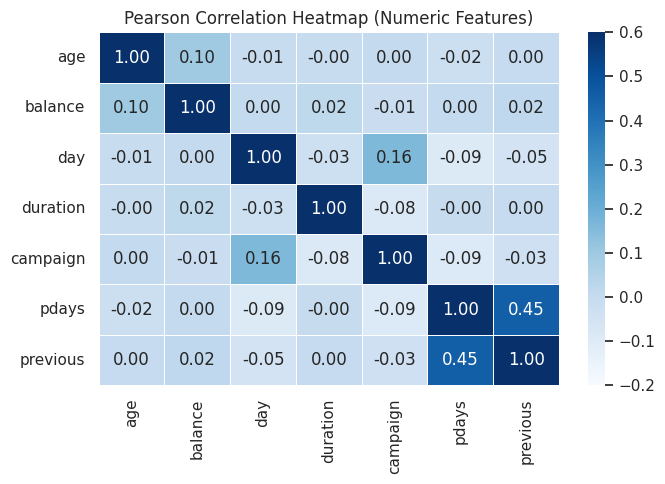

In [28]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=-0.2,
    vmax=0.6,
    linewidths=0.5,
)
plt.title('Pearson Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

     count  percentage
y                     
no   39922        88.3
yes   5289        11.7
Imbalance ratio: 7.55 : 1


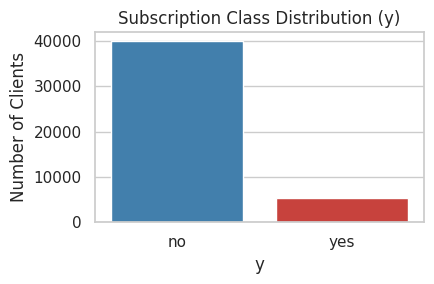

In [31]:
counts = df['y'].value_counts()
pct = (df['y'].value_counts(normalize=True) * 100).round(2)
print(pd.DataFrame({'count': counts, 'percentage': pct}))
print('Imbalance ratio:', round(counts.max() / counts.min(), 2), ': 1')

plt.figure(figsize=(4.5, 3))
sns.countplot(
    x='y',
    data=df,
    hue='y',
    palette=['#3182bd', '#de2d26'],
    legend=False,
)
plt.title('Subscription Class Distribution (y)')
plt.ylabel('Number of Clients')
plt.tight_layout()
plt.show()

In [32]:
pdays_conflict = df[(df['previous'] == 0) & (df['pdays'] != -1)]
pdays_conflict_rev = df[(df['previous'] > 0) & (df['pdays'] == -1)]
print(
    'Inconsistent records (previous == 0 but pdays != -1):', len(pdays_conflict)
)
print(
    'Inconsistent records (previous > 0 but pdays == -1) :',
    len(pdays_conflict_rev),
)

print('\nHousing loan vs Personal loan crosstab:')
pd.crosstab(df['housing'], df['loan'], margins=True)

Inconsistent records (previous == 0 but pdays != -1): 0
Inconsistent records (previous > 0 but pdays == -1) : 0

Housing loan vs Personal loan crosstab:


loan,no,yes,All
housing,,,
no,17204,2877,20081
yes,20763,4367,25130
All,37967,7244,45211


In [33]:
import os
import warnings
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
SEED = 42

In [35]:
df = pd.read_csv('bank-full.csv', sep=';')
print('Raw shape:', df.shape)

initial_len = len(df)
df = df.drop_duplicates()
print(f'Duplicates removed: {initial_len - len(df)} | New shape: {df.shape}')

df['y'] = (df['y'] == 'yes').astype(int)
print('\nTarget class balance:')
print(df['y'].value_counts(normalize=True).round(4))

Raw shape: (45211, 17)
Duplicates removed: 0 | New shape: (45211, 17)

Target class balance:
y
0    0.883
1    0.117
Name: proportion, dtype: float64


In [36]:
X = df.drop(columns=['y'])
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)
print('Positive rate in Train:', round(y_train.mean(), 4))
print('Positive rate in Test :', round(y_test.mean(), 4))

Train shape: (36168, 16) | Test shape: (9043, 16)
Positive rate in Train: 0.117
Positive rate in Test : 0.117


In [37]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print('Unknown count per categorical column (Train set):')
print((X_train[cat_cols] == 'unknown').sum()[(X_train[cat_cols] == 'unknown').sum() > 0])

poutcome_unknown = (X_train['poutcome'] == 'unknown')
print('\nSubscription rate when poutcome is UNKNOWN :', round(y_train[poutcome_unknown].mean(), 3))
print('Subscription rate when poutcome is RECORDED:', round(y_train[~poutcome_unknown].mean(), 3))

Unknown count per categorical column (Train set):
job            234
education     1482
contact      10386
poutcome     29589
dtype: int64

Subscription rate when poutcome is UNKNOWN : 0.092
Subscription rate when poutcome is RECORDED: 0.228


In [63]:
yj = PowerTransformer(method='yeo-johnson')
balance_yj = yj.fit_transform(X_train[['balance']]).flatten()

raw_b = X_train['balance']
yj_b = pd.Series(balance_yj)

transform_table = pd.DataFrame({
    'Metric': ['Mean', 'Std Dev', 'Min', '25% (Q1)', 'Median', '75% (Q3)', 'Max', 'Skewness'],
    'Raw Balance (Pre-Transform)': [
        round(raw_b.mean(), 2),
        round(raw_b.std(), 2),
        round(raw_b.min(), 2),
        round(raw_b.quantile(0.25), 2),
        round(raw_b.median(), 2),
        round(raw_b.quantile(0.75), 2),
        round(raw_b.max(), 2),
        round(raw_b.skew(), 2)
    ],
    'Yeo-Johnson (Post-Transform)': [
        round(yj_b.mean(), 4),
        round(yj_b.std(), 4),
        round(yj_b.min(), 4),
        round(yj_b.quantile(0.25), 4),
        round(yj_b.median(), 4),
        round(yj_b.quantile(0.75), 4),
        round(yj_b.max(), 4),
        round(yj_b.skew(), 2)
    ]
}).set_index('Metric')

display(transform_table)

,Raw Balance (Pre-Transform),Yeo-Johnson (Post-Transform)
Metric,,
Mean,1365.49,0.0000
Std Dev,3068.54,1.0000
Min,-8019.00,-33.7651
25% (Q1),74.00,-0.3836
Median,451.00,-0.2058
75% (Q3),1430.25,0.1666
Max,102127.00,21.1263
Skewness,8.34,1.0000


In [39]:
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

def build_preprocessor():
    num_step = Pipeline([
        ('scaler', StandardScaler())
    ])
    cat_step = Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='unknown')),
        ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=0.01, sparse_output=False))
    ])
    return ColumnTransformer([
        ('num', num_step, num_cols),
        ('cat', cat_step, cat_cols)
    ])

prep = build_preprocessor()

Xtr = prep.fit_transform(X_train)
Xte = prep.transform(X_test)
feature_names = prep.get_feature_names_out()

print('Features before encoding:', X_train.shape[1])
print('Features after encoding :', Xtr.shape[1])
print('Any NaN left in training set?', np.isnan(Xtr).any())

Features before encoding: 16
Features after encoding : 51
Any NaN left in training set? False


In [64]:
mi = pd.Series(mutual_info_classif(Xtr, y_train, random_state=SEED), index=feature_names).sort_values(ascending=False)
print('Top 10 features by Mutual Information:')
print(mi.head(10).round(4))

Top 10 features by Mutual Information:
num__duration            0.0740
cat__poutcome_success    0.0278
num__pdays               0.0261
num__balance             0.0197
cat__housing_yes         0.0176
cat__poutcome_unknown    0.0174
cat__contact_cellular    0.0162
cat__contact_unknown     0.0145
num__previous            0.0140
cat__housing_no          0.0133
dtype: float64


In [43]:
pca = PCA(random_state=SEED).fit(Xtr)
cum_var = np.cumsum(pca.explained_variance_ratio_)

print('Components needed for 90% variance:', int(np.argmax(cum_var >= 0.90)) + 1)
print('Components needed for 95% variance:', int(np.argmax(cum_var >= 0.95)) + 1)
print('Total encoded features            :', Xtr.shape[1])

Components needed for 90% variance: 18
Components needed for 95% variance: 24
Total encoded features            : 51


In [47]:
def evaluate_model(name, model, x_tr, y_tr, x_te, y_te):
    model.fit(x_tr, y_tr)
    preds = model.predict(x_te)
    probs = model.predict_proba(x_te)[:, 1]
    return {
        'setup': name,
        'precision': round(precision_score(y_te, preds), 3),
        'recall': round(recall_score(y_te, preds), 3),
        'f1': round(f1_score(y_te, preds), 3),
        'roc_auc': round(roc_auc_score(y_te, probs), 3),
        'pr_auc': round(average_precision_score(y_te, probs), 3)
    }

def get_lr(**kwargs):
    return LogisticRegression(max_iter=1500, random_state=SEED, **kwargs)

def get_rf(**kwargs):
    return RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1, **kwargs)

In [48]:
exp_results = []

exp_results.append(evaluate_model('LR: Standard pipeline', get_lr(), Xtr, y_train, Xte, y_test))

top25_idx = [list(feature_names).index(col) for col in mi.head(25).index]
exp_results.append(evaluate_model('LR: Top 25 MI features', get_lr(), Xtr[:, top25_idx], y_train, Xte[:, top25_idx], y_test))

pca95 = PCA(n_components=0.95, random_state=SEED).fit(Xtr)
exp_results.append(evaluate_model('LR: PCA 95% variance', get_lr(), pca95.transform(Xtr), y_train, pca95.transform(Xte), y_test))

df_exp = pd.DataFrame(exp_results).set_index('setup')
df_exp

,precision,recall,f1,roc_auc,pr_auc
setup,,,,,
LR: Standard pipeline,0.644,0.348,0.452,0.906,0.545
LR: Top 25 MI features,0.654,0.336,0.444,0.902,0.534
LR: PCA 95% variance,0.603,0.252,0.356,0.881,0.469


In [49]:
print('Training class counts before balancing:', dict(y_train.value_counts()))

Xs, ys = SMOTE(random_state=SEED).fit_resample(Xtr, y_train)
Xo, yo = RandomOverSampler(random_state=SEED).fit_resample(Xtr, y_train)
Xu, yu = RandomUnderSampler(random_state=SEED).fit_resample(Xtr, y_train)

for name, y_resampled in [('SMOTE', ys), ('Random over', yo), ('Random under', yu)]:
    print(name, '->', dict(pd.Series(y_resampled).value_counts()))

bal_results = []
for model_name, get_model in [('Logistic regression', get_lr), ('Random forest', get_rf)]:
    bal_results.append(evaluate_model(f'{model_name}: none', get_model(), Xtr, y_train, Xte, y_test))
    bal_results.append(evaluate_model(f'{model_name}: class_weight', get_model(class_weight='balanced'), Xtr, y_train, Xte, y_test))
    bal_results.append(evaluate_model(f'{model_name}: random over-sampling', get_model(), Xo, yo, Xte, y_test))
    bal_results.append(evaluate_model(f'{model_name}: random under-sampling', get_model(), Xu, yu, Xte, y_test))
    bal_results.append(evaluate_model(f'{model_name}: SMOTE', get_model(), Xs, ys, Xte, y_test))

bal_table = pd.DataFrame(bal_results).set_index('setup')
bal_table

Training class counts before balancing: {0: np.int64(31937), 1: np.int64(4231)}
SMOTE -> {0: np.int64(31937), 1: np.int64(31937)}
Random over -> {0: np.int64(31937), 1: np.int64(31937)}
Random under -> {0: np.int64(4231), 1: np.int64(4231)}


,precision,recall,f1,roc_auc,pr_auc
setup,,,,,
Logistic regression: none,0.644,0.348,0.452,0.906,0.545
Logistic regression: class_weight,0.418,0.815,0.553,0.908,0.538
Logistic regression: random over-sampling,0.417,0.819,0.552,0.908,0.537
Logistic regression: random under-sampling,0.411,0.811,0.546,0.907,0.536
Logistic regression: SMOTE,0.419,0.804,0.551,0.907,0.538
Random forest: none,0.676,0.409,0.510,0.929,0.618
Random forest: class_weight,0.692,0.344,0.460,0.927,0.614
Random forest: random over-sampling,0.602,0.517,0.556,0.928,0.614
Random forest: random under-sampling,0.405,0.884,0.555,0.926,0.597


In [53]:
final_pipeline = Pipeline([
    ('prep', build_preprocessor()),
    ('model', get_lr(class_weight='balanced'))
])

final_pipeline.fit(X_train, y_train)
final_preds = final_pipeline.predict(X_test)
final_probs = final_pipeline.predict_proba(X_test)[:, 1]

print('Final Pipeline Steps:', [step[0] for step in final_pipeline.steps])
print('Precision :', round(precision_score(y_test, final_preds), 3))
print('Recall    :', round(recall_score(y_test, final_preds), 3))
print('F1-Score  :', round(f1_score(y_test, final_preds), 3))
print('ROC-AUC   :', round(roc_auc_score(y_test, final_probs), 3))
print('PR-AUC    :', round(average_precision_score(y_test, final_probs), 3))

Final Pipeline Steps: ['prep', 'model']
Precision : 0.418
Recall    : 0.815
F1-Score  : 0.553
ROC-AUC   : 0.908
PR-AUC    : 0.538
